# Heart Disease Classification – Neural Network vs BDT

In this two-part tutorial we compare two machine learning models for binary classification:

- Part 1: A small Neural Network (NN)
- Part 2: A Boosted Decision Tree (BDT)

We use the [Heart Disease dataset](https://www.openml.org/search?type=data&status=active&id=43682) from OpenML to classify:

- 0 → No heart disease
- 1 → Heart disease

Since this is a medical application, we will carefully evaluate:

- Training behavior (over/underfitting)
- Feature importance
- Prediction distributions
- ROC curves
- Sensitivity and specificity

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nairods/Scies4Free-FastML-tutorial/blob/main/part0.ipynb)

## 1. Import Libraries

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from scipy.io import arff

%matplotlib inline
RANDOM_STATE = 42

## 2. Load and Inspect the Dataset

In [110]:
data = fetch_openml('Heart-Disease-Dataset-(Comprehensive)', version=2)
df = data.frame

### LOAD DATA LOCALLY IN CASE OPENML GIVES PROBLEMS
# !git clone https://github.com/nairods/Scies4Free-FastML-tutorial.git
# DATA_PATH = "Scies4Free-FastML-tutorial/data/"
# data, meta = arff.loadarff(DATA_PATH + "dataset")   # use your filename
# df = pd.DataFrame(data)

X = df.drop(columns=['target'])
y = df['target']

print("\nFirst 5 rows of data:")
display(X.head())

print("\nClass distribution:")
print(pd.Series(y).value_counts())


First 5 rows of data:


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0



Class distribution:
target
1.0    629
0.0    561
Name: count, dtype: int64


## Feature explanation

| Feature             | Meaning                                                                                                             |
| ------------------- | ------------------------------------------------------------------------------------------------------------------- |
| age                 | Age in years.                                                                                  |
| sex                 | Sex (1 = male, 0 = female).                                                                |
| chest_pain_type     | Chest pain type (categorical, 1–4).                                                 |
| resting_bp_s        | Resting blood pressure (mm Hg).                                                |
| cholesterol         | Serum cholesterol (mg/dL).                               |
| fasting_blood_sugar | Fasting blood sugar > 120 mg/dL (1 = true, 0 = false).                                                 |
| resting_ecg         | Resting ECG results (categorical, 0–2).                                             |
| max_heart_rate      | Maximum heart rate achieved.                                                                |
| exercise_angina     | Exercise-induced angina (1 = yes, 0 = no).                                 |
| oldpeak             | ST depression induced by exercise relative to rest.                       |
| ST_slope            | Slope of the peak exercise ST segment (categorical, 0–3).
| target              | Diagnosis label (1 = heart disease, 0 = no disease).                        |

## 3. Train/Test Split

We keep a separate test set that is **not** used during model development.

- **Train**: used to fit model parameters (weights/trees).
- **Validation**: used to tune hyperparameters and for early stopping / model selection.
- **Test**: used once at the end for final reporting and comparison.

This avoids “test set leakage” (accidentally tuning on the test set).

In [111]:
# Train/val/test split: stratify = keep class balance, test_size = test/val fraction.
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.50, random_state=RANDOM_STATE, stratify=y_val_test
)
# Train: 70%, Val: 15%, Test: 15%
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 833
Validation samples: 178
Test samples: 179


## 4. Scale Features (for Neural Network)

Scaling helps neural networks train faster and more stably because gradient-based optimizers behave much better when input features are on a comparable scale (roughly zero mean and unit variance), so no single large‑magnitude feature dominates the gradients.

In [112]:
scaler = StandardScaler()
# Learn the mean/std from training data only to avoid leaking information from val/test into preprocessing:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## 5. Build and Train Small Neural Networks (Baseline + Anti-Overfitting)

We’ll start with a baseline model that tends to overfit, then compare three common mitigation techniques: early stopping, L2 regularization, and dropout.

In [113]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

input_dim = X_train_scaled.shape[1]


## 5.1 The Baseline model (likely to overfit)

We intentionally train longer to make overfitting more visible.

In [114]:
def build_baseline(input_dim):
 model = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu',),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
 ])
 model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 return model

baseline = build_baseline(input_dim)
hist_baseline = baseline.fit(
 X_train_scaled, y_train,
 validation_data=(X_val_scaled, y_val),
 epochs=80,
 batch_size=32,
 verbose=1 # Print training history
)


Epoch 1/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3853 - loss: 0.7491 - val_accuracy: 0.6517 - val_loss: 0.6580
Epoch 2/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6776 - loss: 0.6384 - val_accuracy: 0.7472 - val_loss: 0.5616
Epoch 3/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7408 - loss: 0.5580 - val_accuracy: 0.8034 - val_loss: 0.4755
Epoch 4/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8080 - loss: 0.4707 - val_accuracy: 0.7921 - val_loss: 0.4200
Epoch 5/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8285 - loss: 0.4209 - val_accuracy: 0.8034 - val_loss: 0.3917
Epoch 6/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8161 - loss: 0.3924 - val_accuracy: 0.7978 - val_loss: 0.3797
Epoch 7/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8266 - loss: 0.3785 - val_accuracy: 0.8202 - val_loss: 0.3746
Epoch 8/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8247 - loss: 0.3861 - val_accuracy: 0.8315 - val_loss

### Training History

We plot train vs validation curves for loss and accuracy.

Overtraining (overfitting) happens when training performance keeps improving but validation stops improving (or worsens), indicating the model is memorizing rather than generalizing.

In the loss/accuracy curves, you’ll see the training improving while validation flattens or worsens, so a gap opens between them.

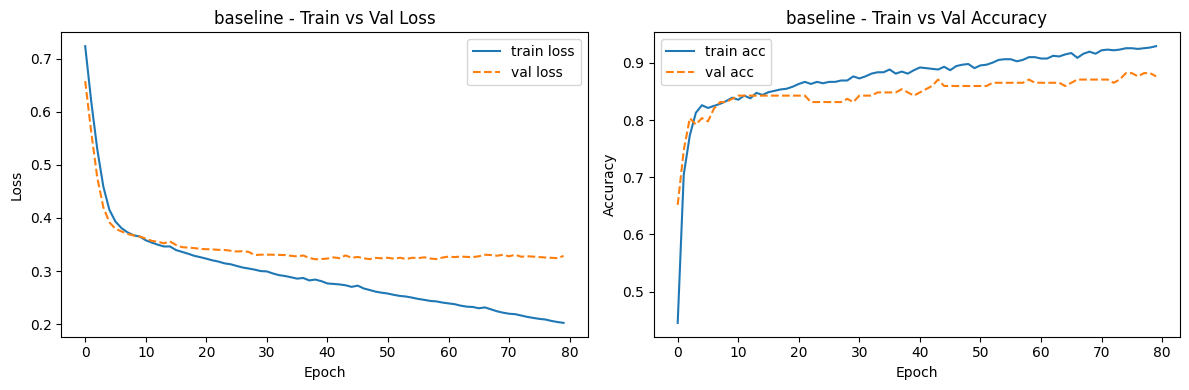

In [115]:
def plot_history(history, name="model", title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)  # 1 row, 2 cols [web:270]

    # Loss
    axes[0].plot(history.history["loss"], label="train loss")
    axes[0].plot(history.history["val_loss"], "--", label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title_prefix}{name} - Train vs Val Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(history.history["accuracy"], label="train acc")
    axes[1].plot(history.history["val_accuracy"], "--", label="val acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title_prefix}{name} - Train vs Val Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

histories = {
 'baseline': hist_baseline,
}

for name, hist in histories.items():
    plot_history(hist, name=name, title_prefix="")

## 5.2 Overtraining mitigation

In this section we introduce three widely used techniques to reduce overtraining and improve generalization:

- Early stopping

- L2 Regularization (weight decay)

- Dropout

### 5.2.1 Early stopping

Early stopping monitors a validation metric during training and stops once it has not improved for a while, to avoid training past the point of best generalization.

In [116]:
early_stop = keras.callbacks.EarlyStopping(
 monitor='val_loss',
 patience=10,
 min_delta=1e-4, # Minimal change in validation loss to count as improvement
 restore_best_weights=True
)

es_model = build_baseline(input_dim)
hist_es = es_model.fit(
 X_train_scaled, y_train,
 validation_data=(X_val_scaled, y_val),
 epochs=200,
 batch_size=32,
 callbacks=[early_stop],
 verbose=0
)


### 5.2.2 L2 Regularization (weight decay)

L2 regularization adds a penalty for large weights to the loss function, encouraging the network to use smaller weights and therefore simpler decision boundaries.

In [117]:
def build_l2(input_dim, l2=1e-3):
 model = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.L2(l2)),
    layers.Dense(16, activation='relu', kernel_regularizer=regularizers.L2(l2)),
    layers.Dense(1, activation='sigmoid')
 ])
 model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 return model

l2_model = build_l2(input_dim, l2=1e-3)
hist_l2 = l2_model.fit(
 X_train_scaled, y_train,
 validation_data=(X_val_scaled, y_val),
 epochs=80,
 batch_size=32,
 verbose=0
)


### 5.2.3 Dropout

Dropout is a regularization technique where, during training, a random fraction of neurons is temporarily “turned off” in each batch. This prevents the network from relying too much on any single path through the model, which reduces co-adaptation and helps generalization.

In [118]:
def build_dropout(input_dim, rate=0.1):
 model = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(rate),
    layers.Dense(16, activation='relu'),
    layers.Dropout(rate),
    layers.Dense(1, activation='sigmoid')
 ])
 model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 return model

do_model = build_dropout(input_dim, rate=0.1)
hist_do = do_model.fit(
 X_train_scaled, y_train,
 validation_data=(X_val_scaled, y_val),
 epochs=80,
 batch_size=32,
 verbose=0
)


## 6. Compare Training History

We plot training vs validation loss/accuracy for each method to see how they affect overfitting (look for a widening train–val gap and where validation stops improving).

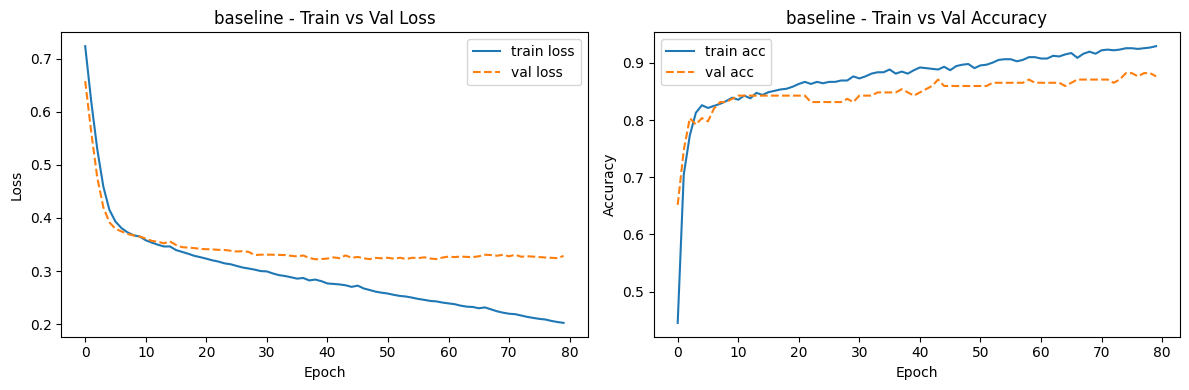

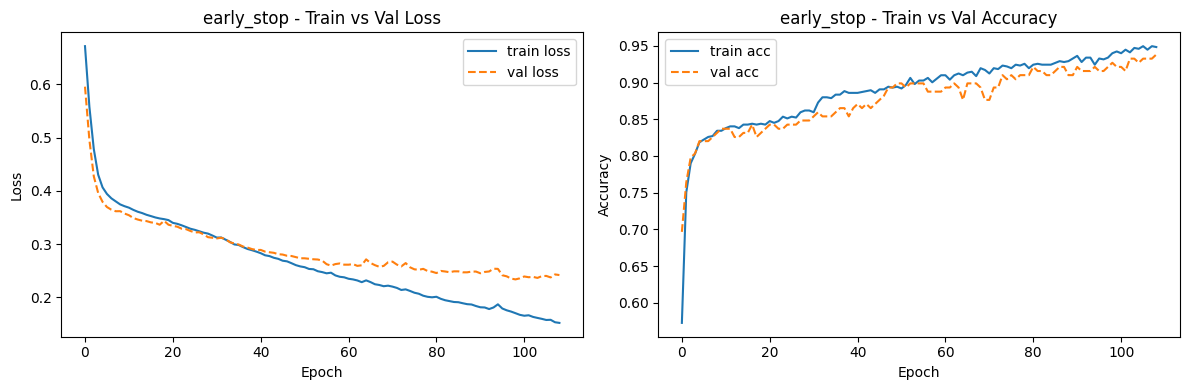

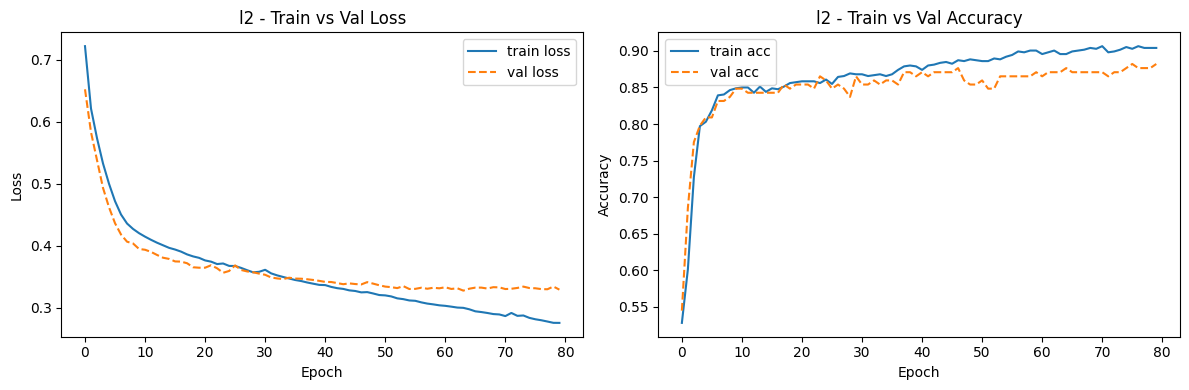

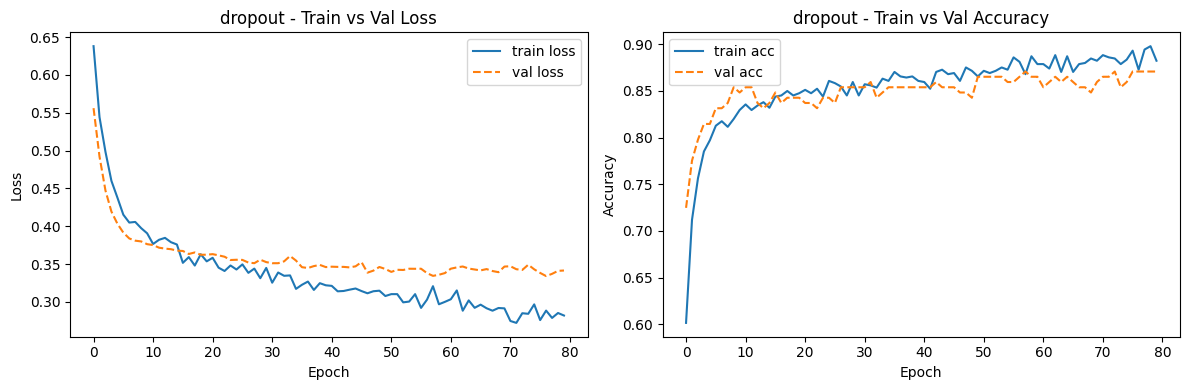

In [119]:
histories = {
 'baseline': hist_baseline,
 'early_stop': hist_es,
 'l2': hist_l2,
 'dropout': hist_do,
}

for name, hist in histories.items():
    plot_history(hist, name=name, title_prefix="")

### Task 1

Experiment with the overfitting mitigation techniques by changing:
- Early stopping: `monitor`, `patience`, `min_delta`
- L2 regularization strength (`l2`)
- Dropout rate

**Goal**: reduce the train–validation gap and improve validation performance (e.g., lower `val_loss` or higher `val_accuracy`) without using the test set for tuning.




-------------------------------------------------------------------------

## 7. Feature Importance

Beyond checking for overfitting, we can also try to understand what the model learned.

Feature importance methods estimate how much each input feature contributes to the predictions.

We look at:
- **Global importance**: which features matter most on average across the dataset.
- **Local explanations**: which features pushed a single prediction toward “disease” or “no disease”.

### SHAP (SHapley Additive exPlanations)

SHAP is an explanation method that assigns each feature a “contribution value” for a prediction.
- **Local**: explains individual samples (why this person was predicted positive/negative).
- **Global**: averaging absolute SHAP values across many samples gives a global importance ranking.

Interpretation:
- A **positive SHAP value** pushes the prediction toward the positive class (e.g., “heart disease”).
- A **negative SHAP value** pushes it toward the negative class.
- The magnitude indicates how strong the contribution is.

PermutationExplainer explainer: 180it [00:25,  4.19it/s]


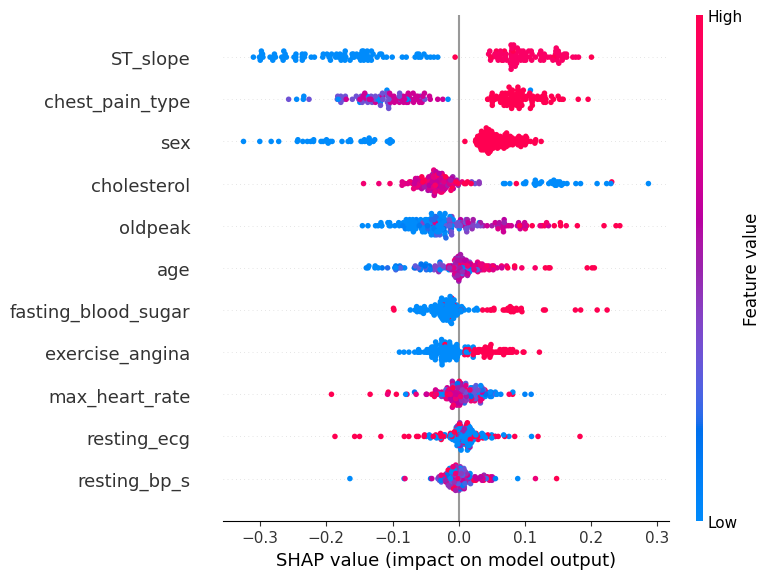

In [120]:
import shap

# Attach the feature names back to the data
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

explainer = shap.Explainer(baseline, X_train_scaled)
shap_values = explainer(X_test_scaled_df)
shap.summary_plot(shap_values, features=X_test_scaled_df, rng=RANDOM_STATE)

### Task 2

Experiment with the input features and observe how model performance changes:

- Remove the **highest-impact** features (from SHAP) and retrain.
- Remove the **lowest-impact** features and retrain.
- Remove a few **random** features and retrain.

**Goal**: study how removing information from the input affects validation/test performance. Record the best val loss and accuracy for comparison.

-------------------------------------------------------------------------

## 8. Prediction Distributions

Many classifiers output a prediction score for each sample (often a probability between 0 and 1).

By plotting the score histograms separately for the true “no disease” and “heart disease” groups, we can see how well the model separates the classes: less overlap means clearer separation and makes choosing a decision threshold easier.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


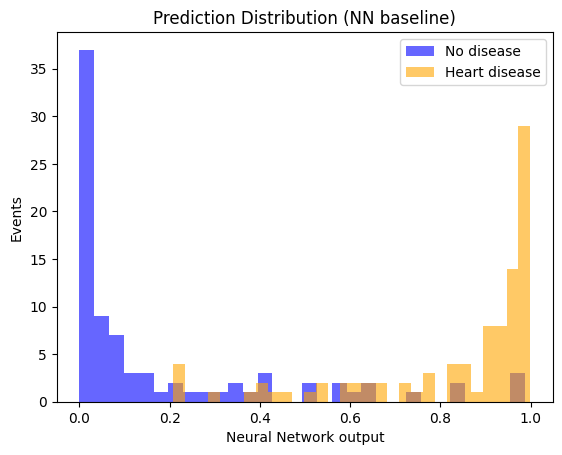

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


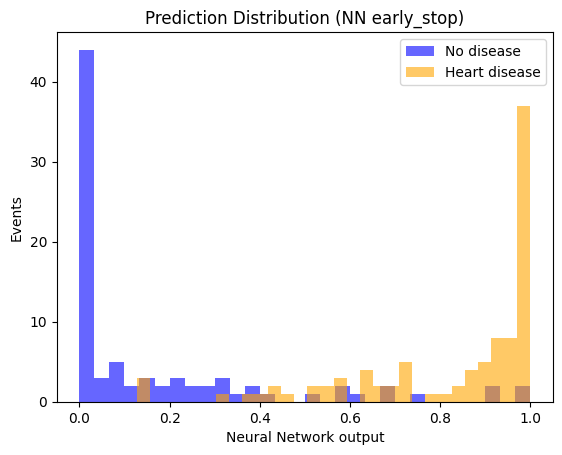

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


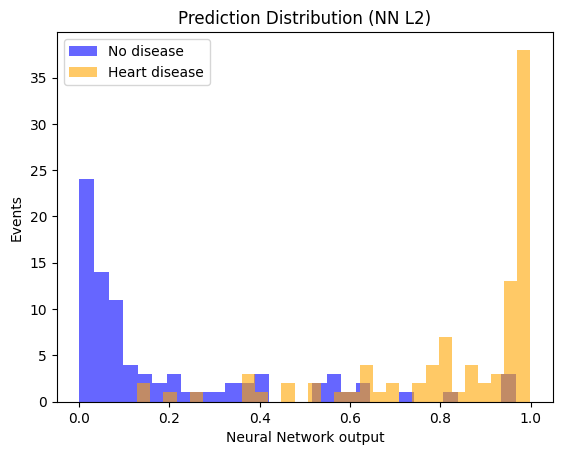

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


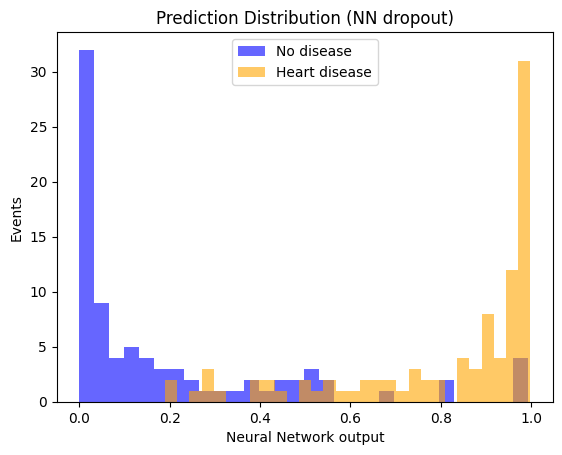

In [121]:
def plot_pred_distribution(name, scores, y, *, xlabel, bins=30):
    plt.figure()
    plt.hist(scores[y == 0], bins=bins, alpha=0.6, label="No disease", color="blue")
    plt.hist(scores[y == 1], bins=bins, alpha=0.6, label="Heart disease", color="orange")
    plt.xlabel(xlabel)
    plt.ylabel("Events")
    plt.legend()
    plt.title(f"Prediction Distribution ({name})")
    plt.show()

models = [
    ("NN baseline",    lambda: baseline.predict(X_test_scaled).ravel(),  "Neural Network output"),
    ("NN early_stop",  lambda: es_model.predict(X_test_scaled).ravel(),  "Neural Network output"),
    ("NN L2",          lambda: l2_model.predict(X_test_scaled).ravel(),  "Neural Network output"),
    ("NN dropout",     lambda: do_model.predict(X_test_scaled).ravel(),  "Neural Network output"),
]

for name, get_scores, xlabel in models:
    scores = get_scores()
    plot_pred_distribution(name, scores, y_test, xlabel=xlabel)

## 9. ROC Curve Comparison

In this section we compare models using the ROC curve, which plots the true positive rate (sensitivity/recall) against the false positive rate for all possible decision thresholds. Unlike accuracy (which depends on picking one fixed threshold like 0.5), the ROC curve summarizes how well a model ranks positive cases higher than negative cases across the full range of thresholds.

To make comparison easier, we also report the area under the ROC curve (ROC–AUC): values closer to 1.0 indicate better discrimination, while 0.5 corresponds to random guessing. \
When overlaying multiple ROC curves, the model whose curve lies closer to the top-left corner (higher TPR at the same FPR) is generally preferable, but the “best” choice still depends on whether you care more about avoiding false positives or missing true positives.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
NN baseline
  Best threshold: 0.440
  Sensitivity: 0.916, Specificity: 0.845
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
NN early_stop
  Best threshold: 0.440
  Sensitivity: 0.937, Specificity: 0.869
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
NN L2
  Best threshold: 0.645
  Sensitivity: 0.832, Specificity: 0.940
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
NN dropout
  Best threshold: 0.560
  Sensitivity: 0.832, Specificity: 0.917


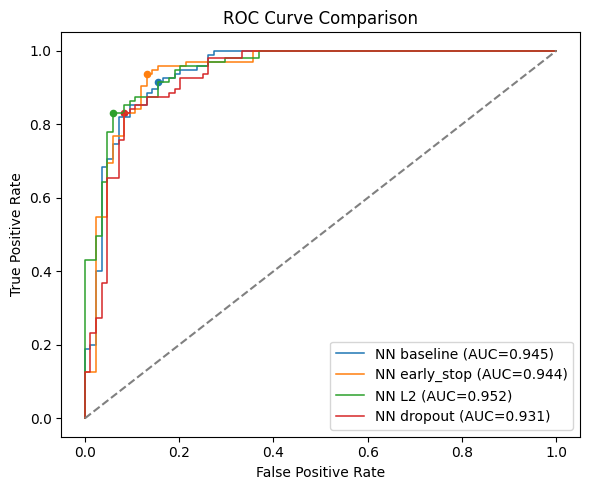

In [122]:
from sklearn.metrics import roc_curve, roc_auc_score

def best_threshold(fpr, tpr, thr, w_sens=0.5):
    # Computes the generalized Youden index J = w * sensitivity - (1-w) * FPR,
    # where w_sens controls the sensitivity/specificity tradeoff
    j = w_sens * tpr - (1 - w_sens) * fpr
    k = int(np.argmax(j))
    return float(thr[k]), float(tpr[k]), float(1 - fpr[k])


plt.figure(figsize=(6, 5))

for name, get_scores, _ in models:

    scores = get_scores()
    fpr, tpr, thr = roc_curve(y_test, scores)

    thr_best, sens, spec = best_threshold(fpr, tpr, thr)
    auc = roc_auc_score(y_test, scores)

    print(name)
    print(f"  Best threshold: {thr_best:.3f}")
    print(f"  Sensitivity: {sens:.3f}, Specificity: {spec:.3f}")

    plt.plot(fpr, tpr, linewidth=1.1, label=f"{name} (AUC={auc:.3f})")
    # optional: mark operating point
    plt.scatter([1 - spec], [sens], s=20)

# Chance diagonal
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Medical Evaluation: Sensitivity vs Specificity
In medical diagnostics, missing a heart-disease case (a false negative) can be more harmful than sending a healthy person for follow-up (a false positive).

Sensitivity and specificity describe these two error modes: sensitivity (true positive rate) is the fraction of truly sick patients correctly flagged as sick, TP/(TP+FN), while specificity (true negative rate) is the fraction of truly healthy patients correctly cleared as healthy, TN/(TN+FP). There is usually a trade-off: pushing sensitivity up typically reduces specificity, so we need to pick an operating threshold that matches the medical goal.

### Task 3

Run the ROC code 3 times with different `w_sens` values and record the results:

1. `w_sens=0.3` (prioritizes specificity)
2. `w_sens=0.5` (balanced, classic Youden index)
3. `w_sens=0.7` (prioritizes sensitivity)

**Make a table** (print or draw) with columns: \
Model | w_sens | Threshold | Sensitivity | Specificity

**Questions:**
- How does the optimal threshold change as `w_sens` increases?
- Where do the coloured dots move on the ROC curve?
- For heart disease detection, which `w_sens` makes the most sense and why?

-------------------------------------------------------------------------

# Part 2: Boosted Decision Trees (BDTs)

## 11. Train a BDT

While neural networks learn continuous patterns through layers, Boosted Decision Trees (BDTs) split data hierarchically with simple yes/no questions, then combine many weak trees into a strong predictor.

That's why they don't need scaling/normalization, handle outliers and many features automatically (filtering bad ones easily), and shine on small tabular datasets like ours. All while staying fast, simple, and interpretable through clear feature importance.

In [131]:
from xgboost import XGBClassifier

eval_set = [(X_train, y_train), (X_val, y_val)]


xgb_baseline = XGBClassifier(
    n_estimators=100,               # Number of boosting rounds (trees)
    learning_rate=0.02,             # Step size (small = more stable, slower)
    max_depth=3,                    # Max tree depth (controls overfitting)
    objective="binary:logistic",    # Output probabilities for binary classification
    eval_metric=["logloss", "auc"], # Track loss + ROC-AUC during training
    random_state=RANDOM_STATE
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

evals_base = xgb_baseline.evals_result()

BDTs are naturally resistant to overfitting thanks to built-in safeguards like tree depth limits and shrinkage, but XGBoost also offers powerful tools like early stopping and regularization if needed.

In [124]:
xgb_regularized = XGBClassifier(
    # Give a larger cap and let early stopping choose the effective number of trees.
    n_estimators=200,
    learning_rate=0.02,
    max_depth=3,

    # Overfitting mitigation knobs (BDT equivalents of regularization)
    min_child_weight=5, # Minimum sum of instance weight (roughly: min samples) needed in a child. Higher => less overfitting.
    gamma=0.2, # Minimum loss reduction required to make a split. Higher => simpler trees.
    subsample=0.8, # Row subsampling per tree (injects randomness, reduces variance).
    colsample_bytree=0.8, # Feature subsampling per tree (also reduces variance, like “feature dropout”).
    reg_lambda=10.0, # L2 regularization on leaf weights. Higher => less overfit.
    # reg_alpha=0.5, # Optional L1 regularization on leaf weights; can further sparsify/shrink.

    objective="binary:logistic",
    eval_metric=["logloss", "auc"], #By default, early stopping monitors the last metric in "eval_metric".
    early_stopping_rounds=10, # Stop if the monitored validation metric does not improve for N rounds.
    random_state=RANDOM_STATE
)

xgb_regularized.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

evals_reg = xgb_regularized.evals_result()

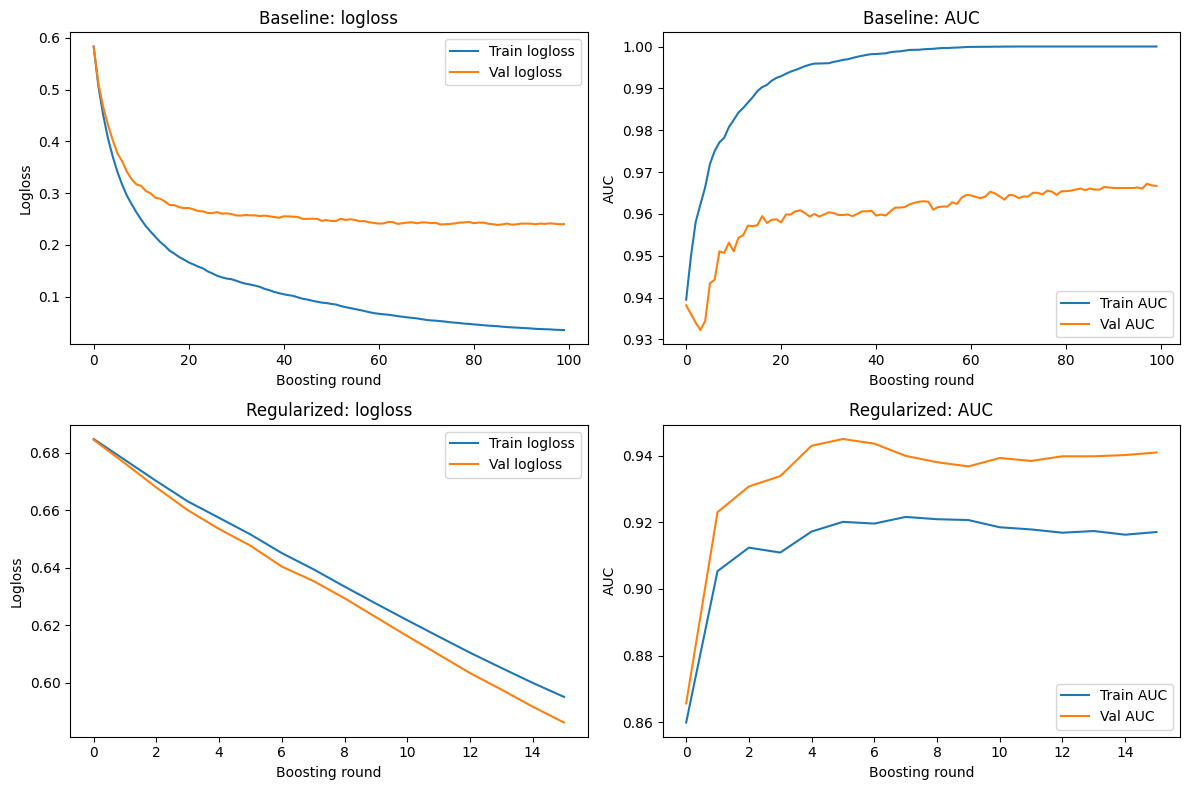

In [132]:
rounds_base = range(len(evals_base["validation_0"]["logloss"]))
rounds_reg  = range(len(evals_reg["validation_0"]["logloss"]))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(rounds_base, evals_base["validation_0"]["logloss"], label="Train logloss")
ax[0, 0].plot(rounds_base, evals_base["validation_1"]["logloss"], label="Val logloss")
ax[0, 0].set(xlabel="Boosting round", ylabel="Logloss", title="Baseline: logloss")
ax[0, 0].legend()

ax[0, 1].plot(rounds_base, evals_base["validation_0"]["auc"], label="Train AUC")
ax[0, 1].plot(rounds_base, evals_base["validation_1"]["auc"], label="Val AUC")
ax[0, 1].set(xlabel="Boosting round", ylabel="AUC", title="Baseline: AUC")
ax[0, 1].legend()

ax[1, 0].plot(rounds_reg, evals_reg["validation_0"]["logloss"], label="Train logloss")
ax[1, 0].plot(rounds_reg, evals_reg["validation_1"]["logloss"], label="Val logloss")
ax[1, 0].set(xlabel="Boosting round", ylabel="Logloss", title="Regularized: logloss")
ax[1, 0].legend()

ax[1, 1].plot(rounds_reg, evals_reg["validation_0"]["auc"], label="Train AUC")
ax[1, 1].plot(rounds_reg, evals_reg["validation_1"]["auc"], label="Val AUC")
ax[1, 1].set(xlabel="Boosting round", ylabel="AUC", title="Regularized: AUC")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

### Task 4

Try to overtrain the baseline BDT and then fix it using XGBoost's built‑in tools.

- Overtrain first: increase `n_estimators`, `learning_rate`, and `max_depth`

- Keep `n_estimators` and `max_depth` consistent across baseline and regularized models

- Then mitigate: tune regularization (`gamma`, `reg_lambda`), use early stopping, or reduce `learning_rate`

Goal: Close the train/test performance gap without sacrificing accuracy.

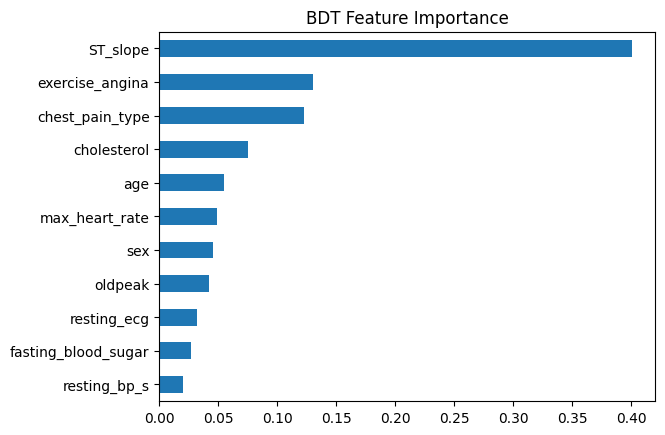

In [126]:
importances = pd.Series(xgb_baseline.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('BDT Feature Importance')
plt.show()

Prediction distributions

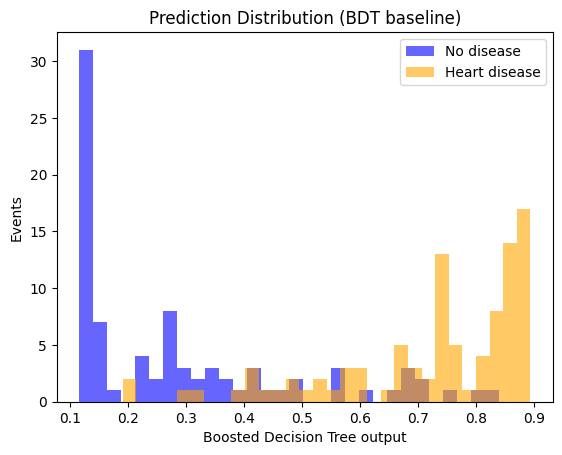

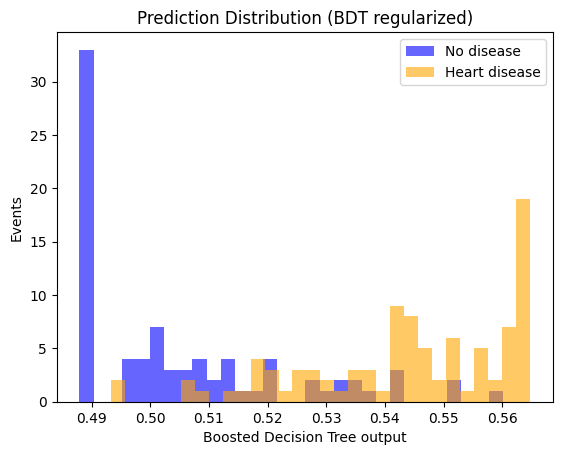

In [127]:
models = [
    ("BDT baseline",   lambda: xgb_baseline.predict_proba(X_test)[:, 1], "Boosted Decision Tree output"),
    ("BDT regularized",lambda: xgb_regularized.predict_proba(X_test)[:, 1], "Boosted Decision Tree output"),
]

for name, get_scores, xlabel in models:
    scores = get_scores()
    plot_pred_distribution(name, scores, y_test, xlabel=xlabel)

roc curves

BDT baseline
  Best threshold: 0.433
  Sensitivity: 0.916, Specificity: 0.810
BDT regularized
  Best threshold: 0.518
  Sensitivity: 0.926, Specificity: 0.774


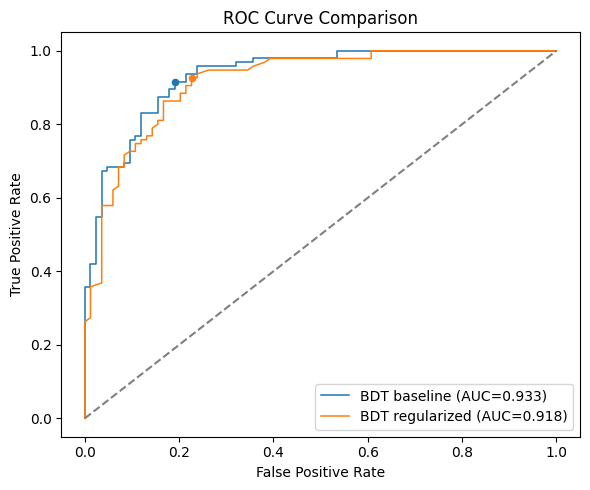

In [128]:
from sklearn.metrics import roc_curve, roc_auc_score

def best_threshold(fpr, tpr, thr, w_sens=0.5):
    j = w_sens * tpr - (1 - w_sens) * fpr
    k = int(np.argmax(j))
    return float(thr[k]), float(tpr[k]), float(1 - fpr[k])

keep = {1, 2, 3, 4, 5, 6}

plt.figure(figsize=(6, 5))

for i, (name, get_scores, _) in enumerate(models, start=1):
    if i not in keep:
        continue

    scores = get_scores()
    fpr, tpr, thr = roc_curve(y_test, scores)

    thr_best, sens, spec = best_threshold(fpr, tpr, thr)
    auc = roc_auc_score(y_test, scores)

    print(name)
    print(f"  Best threshold: {thr_best:.3f}")
    print(f"  Sensitivity: {sens:.3f}, Specificity: {spec:.3f}")

    plt.plot(fpr, tpr, linewidth=1.1, label=f"{name} (AUC={auc:.3f})")
    # optional: mark operating point
    plt.scatter([1 - spec], [sens], s=20)

# Chance diagonal
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Medical Evaluation: Sensitivity vs Specificity
In medical diagnostics, missing a heart-disease case (a false negative) can be more harmful than sending a healthy person for follow-up (a false positive). Sensitivity and specificity describe these two error modes: sensitivity (true positive rate) is the fraction of truly sick patients correctly flagged as sick, TP/(TP+FN), while specificity (true negative rate) is the fraction of truly healthy patients correctly cleared as healthy, TN/(TN+FP). There is usually a trade-off: pushing sensitivity up typically reduces specificity, so we need to pick an operating threshold that matches the medical goal.

**Task:**\
Go back to the confusion-matrix code and replace the fixed threshold (0.5) with an automatically chosen threshold that prioritizes sensitivity using a weighted ROC scan (weighted Youden-style objective). The classic Youden index weights sensitivity and specificity equally, but it can be generalized by assigning a higher weight to sensitivity when false negatives are more costly.